# Wine Quality Prediction — Classification Models

**Objective:** Train and compare multiple classification models to predict the quality of red wine based on its physicochemical properties (acidity, density, alcohol content, etc.).

**Dataset:** `winequality-red.csv` (UCI Wine Quality dataset) — 1,599 red wine samples, 11 physicochemical features, and a `quality` score (integer, 3–8) assigned by wine tasters.

**Tech stack:** Python, pandas, numpy, scikit-learn (RandomForest, SGD, SVC), seaborn, matplotlib

## 1. Load Dataset & Inspect Structure

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
RANDOM_STATE = 42

df = pd.read_csv('winequality-red.csv')
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 1,599 rows x 12 columns


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


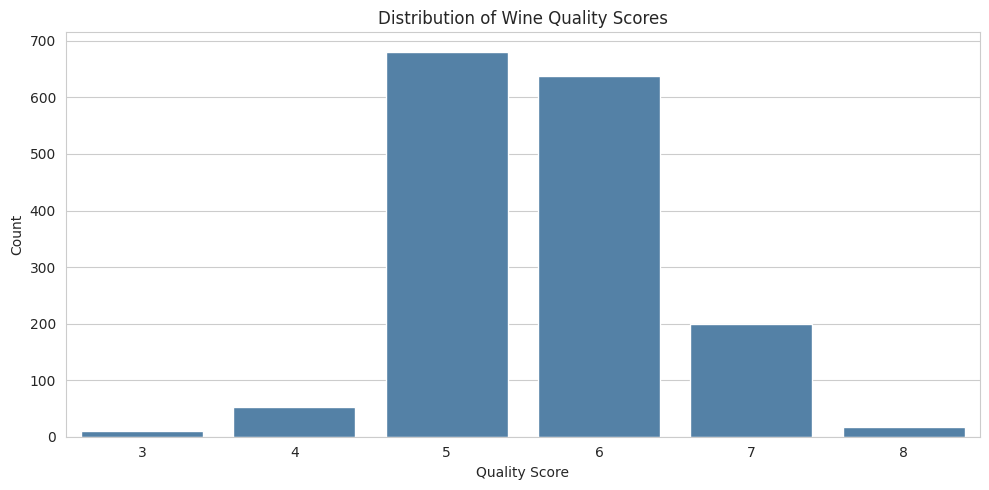

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

In [3]:
fig, ax = plt.subplots()
sns.countplot(x='quality', data=df, ax=ax, color='steelblue')
ax.set_title('Distribution of Wine Quality Scores')
ax.set_xlabel('Quality Score')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

df['quality'].value_counts().sort_index()

**Observations:**
- No missing values in any of the 12 columns.
- All 11 predictor features are continuous (`float64`); `quality` is an integer target ranging from **3 to 8** — note the theoretical scale is 0–10, but no wine in this sample scored below 3 or above 8.
- The class distribution is **heavily skewed toward the middle**: quality 5 and 6 together account for **1,319 of 1,599 samples (82.5%)**, while the extremes (3 and 8) have only **10 and 18 samples** respectively. This is explored further in Section 3.
- **240 exact duplicate rows** exist (identical values across all 12 columns). These are not treated as data errors — with only 11 continuous features rounded to 1–3 decimal places, it's entirely plausible for two different wine samples to share identical measured values by chance, and many wine-quality studies retain them. They are kept in this analysis, but this is worth knowing since it affects how much genuinely distinct information is in the dataset.

## 2. Exploratory Data Analysis

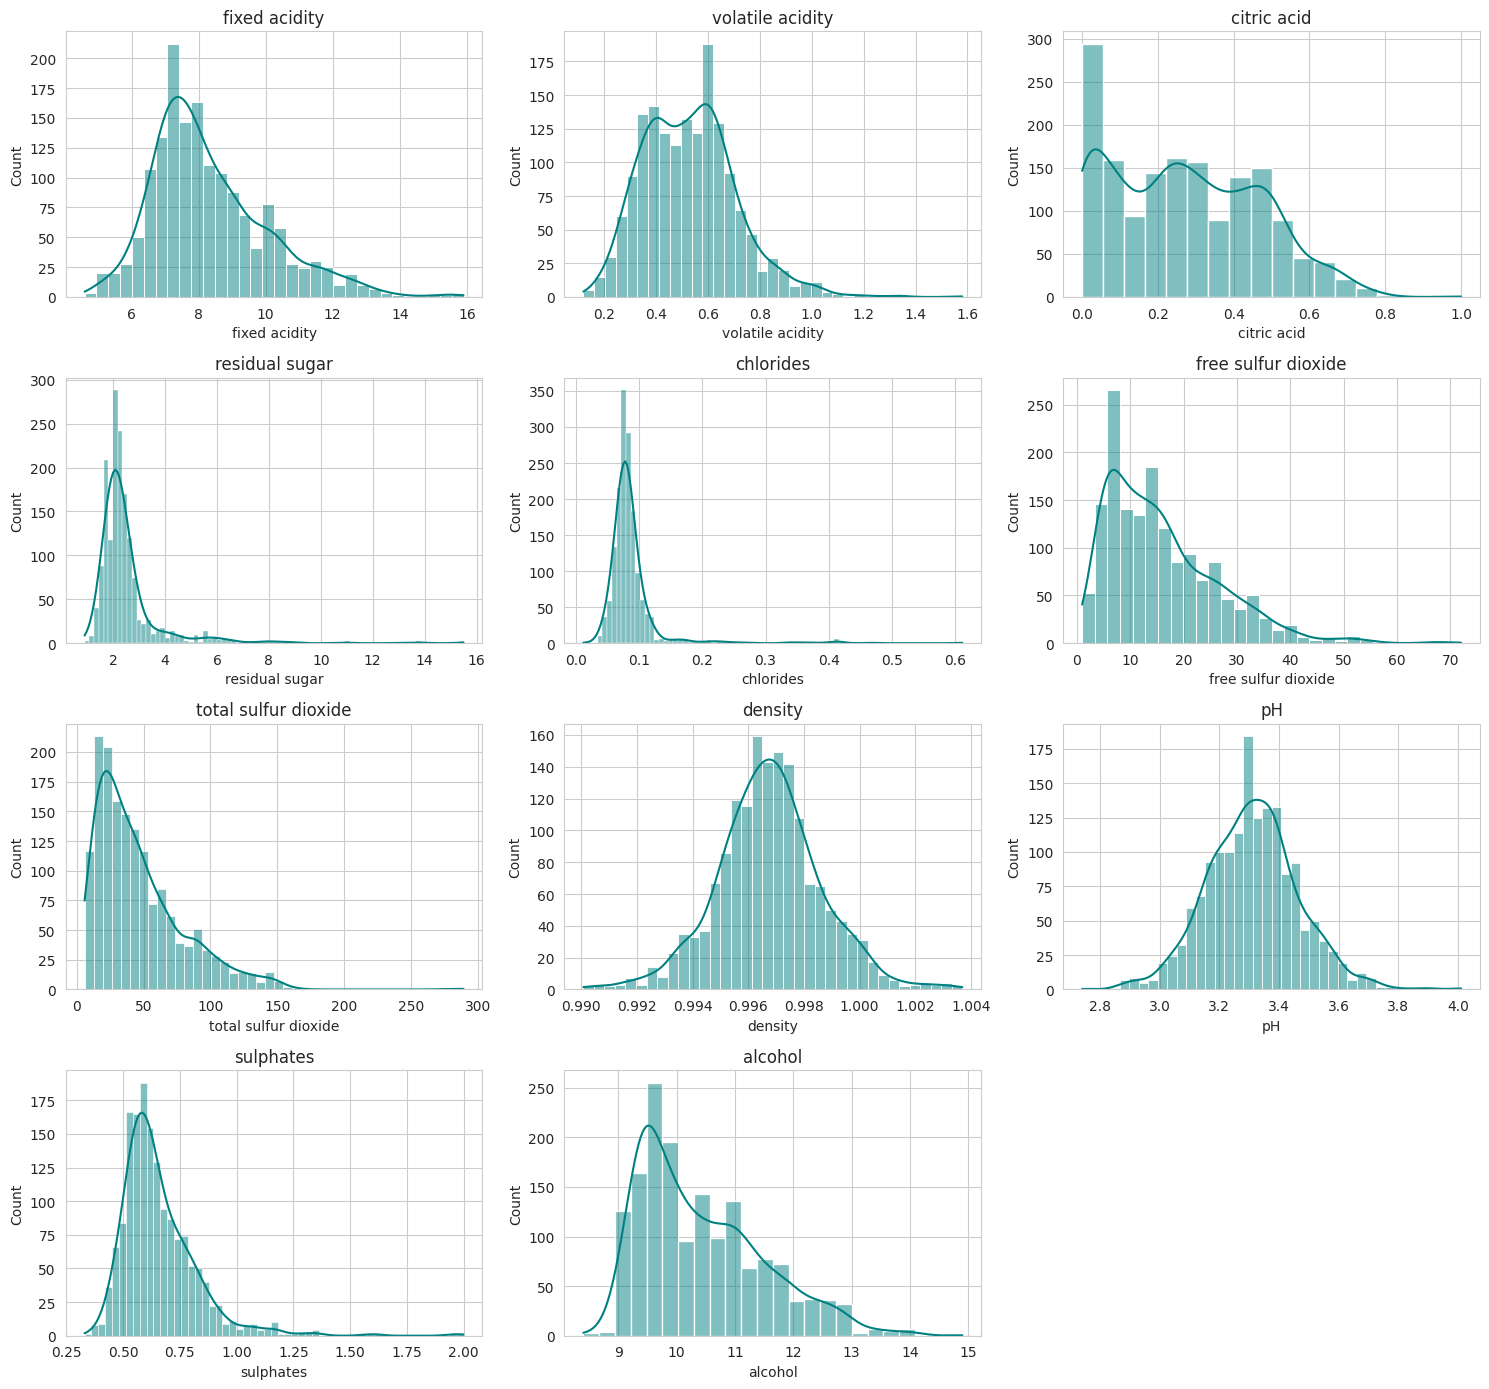

In [4]:
feature_cols = [c for c in df.columns if c != 'quality']

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()
plt.show()

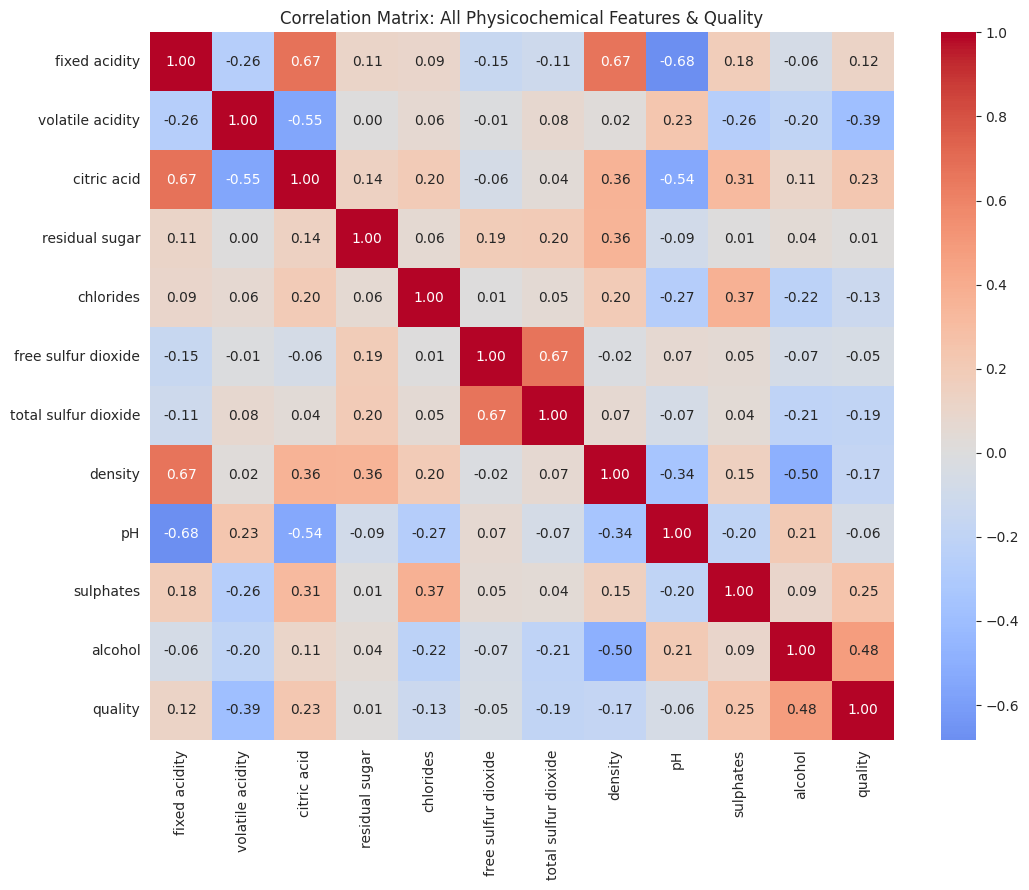

In [5]:
fig, ax = plt.subplots(figsize=(11, 9))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix: All Physicochemical Features & Quality')
plt.tight_layout()
plt.show()

**Observations:**
- Most features are right-skewed (e.g. `residual sugar`, `chlorides`, `sulphates`, `total sulfur dioxide`), with long tails of high-value outliers — common for chemical concentration measurements, which can't go below zero but have no hard upper limit.
- `alcohol` has the strongest positive correlation with `quality` (~0.48) — higher-alcohol wines tend to be rated better in this sample.
- `volatile acidity` has the strongest negative correlation with `quality` (~-0.39) — consistent with wine science, since high volatile acidity is associated with an unpleasant vinegar taste.
- `fixed acidity` and `citric acid`, and `free sulfur dioxide` and `total sulfur dioxide`, are strongly correlated with each other (as expected, since they measure related chemical properties) — worth keeping in mind for models sensitive to multicollinearity, though tree-based models like Random Forest are unaffected by this.

## 3. Class Imbalance Discussion

As seen in Section 1, the raw 6-class distribution (scores 3–8) is severely imbalanced:

| Quality | Count | % of data |
|---|---|---|
| 3 | 10 | 0.6% |
| 4 | 53 | 3.3% |
| 5 | 681 | 42.6% |
| 6 | 638 | 39.9% |
| 7 | 199 | 12.4% |
| 8 | 18 | 1.1% |

**Why this matters for modelling:**
- With only **10 and 18 samples** for quality 3 and 8, any model has almost no evidence to learn what separates an "excellent" or "very poor" wine from its neighbours — a train/test split could easily leave a class with zero test examples, or too few training examples to generalise at all.
- A model that just predicts the majority classes (5 or 6) for everything would already score **~82% "accuracy"** on the raw 6-class problem without learning anything meaningful — accuracy alone would be a misleading metric here.
- This motivates the **feature engineering decision in Section 4**: collapsing the 6 fine-grained scores into fewer, better-populated classes makes the problem tractable, while still preserving a meaningful, business-relevant distinction in wine quality.

## 4. Feature Engineering: Binning Quality Scores

**Decision: binary classification — "Good" (quality ≥ 7) vs. "Not Good" (quality ≤ 6).**

Two options were considered:
- **3-class (low/medium/high):** e.g. low (3–4), medium (5–6), high (7–8). This still leaves the "low" class with only 63 samples (3.9%) — barely more workable than the raw 6-class problem, and a 3-class model is harder to evaluate/deploy than a binary one.
- **Binary (good/bad):** collapses to two classes. The `quality >= 7` threshold is the standard convention used in wine-quality literature and gives a clear, actionable business question: *"is this wine good enough to be classified as high quality?"* This is also more useful for a real deployment scenario (e.g. flagging batches for premium labelling) than a finer-grained score a model can't reliably predict anyway.

The resulting binary target is still imbalanced (~13.6% "Good"), which is addressed via **stratified train/test splitting** (Section 5) and **`class_weight='balanced'`** in every model that supports it (Section 6), rather than discarding data or synthesising samples.

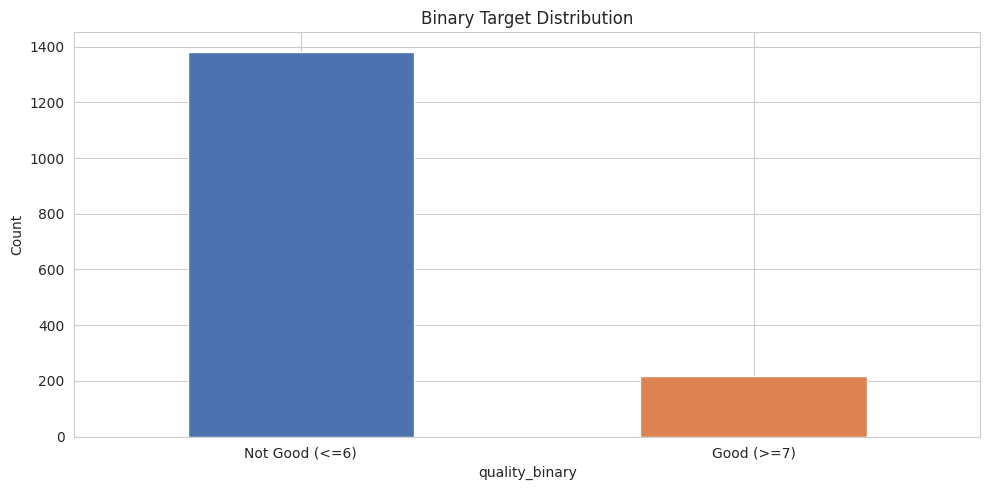

quality_binary
Not Good (<=6)    0.864
Good (>=7)        0.136
Name: proportion, dtype: float64


In [6]:
df['quality_binary'] = np.where(df['quality'] >= 7, 1, 0)
label_map = {0: 'Not Good (<=6)', 1: 'Good (>=7)'}

fig, ax = plt.subplots()
df['quality_binary'].map(label_map).value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Binary Target Distribution')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df['quality_binary'].value_counts(normalize=True).rename(index=label_map).round(3))

## 5. Train/Test Split (Stratified)

In [7]:
X = df[feature_cols]
y = df['quality_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print("Train class ratio:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test class ratio: ", y_test.value_counts(normalize=True).round(3).to_dict())

Train set: 1279 rows | Test set: 320 rows
Train class ratio: {0: 0.864, 1: 0.136}
Test class ratio:  {0: 0.866, 1: 0.134}


**Observation:** stratifying on `quality_binary` ensures the ~86.4% / 13.6% class split is preserved almost identically in both the training and test sets — without this, a random split could easily under- or over-represent the minority "Good" class in the test set, making evaluation metrics unreliable.

## 6. Train 3 Classifiers

`SGDClassifier` and `SVC` are both distance/gradient-based and sensitive to feature scale, so their features are standardised. `RandomForestClassifier` is scale-invariant (it splits on thresholds per feature independently) so it's trained on the raw features. All three use `class_weight='balanced'` to compensate for the imbalance identified in Section 3, rather than letting the models default to always predicting the majority class.

In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {}

# 1) Random Forest -- unscaled features
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
models['Random Forest'] = (rf, X_test)

# 2) SGD Classifier -- scaled features (gradient-based, sensitive to feature scale)
sgd = SGDClassifier(loss='log_loss', class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000)
sgd.fit(X_train_scaled, y_train)
models['SGD Classifier'] = (sgd, X_test_scaled)

# 3) Support Vector Classifier -- scaled features (distance-based)
svc = SVC(kernel='rbf', class_weight='balanced', random_state=RANDOM_STATE, probability=False)
svc.fit(X_train_scaled, y_train)
models['SVC'] = (svc, X_test_scaled)

print("All 3 models trained.")

All 3 models trained.


## 7. Evaluate Each Model: Accuracy, Classification Report, Confusion Matrix

In [9]:
results = {}

for name, (model, X_te) in models.items():
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {
        'y_pred': y_pred,
        'accuracy': acc,
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
    }
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred, target_names=['Not Good', 'Good']))


Random Forest
Accuracy: 0.947
              precision    recall  f1-score   support

    Not Good       0.95      1.00      0.97       277
        Good       0.96      0.63      0.76        43

    accuracy                           0.95       320
   macro avg       0.95      0.81      0.87       320
weighted avg       0.95      0.95      0.94       320


SGD Classifier
Accuracy: 0.838
              precision    recall  f1-score   support

    Not Good       0.96      0.84      0.90       277
        Good       0.44      0.79      0.57        43

    accuracy                           0.84       320
   macro avg       0.70      0.82      0.73       320
weighted avg       0.89      0.84      0.86       320


SVC
Accuracy: 0.847
              precision    recall  f1-score   support

    Not Good       0.96      0.86      0.91       277
        Good       0.46      0.77      0.57        43

    accuracy                           0.85       320
   macro avg       0.71      0.81      0.74 

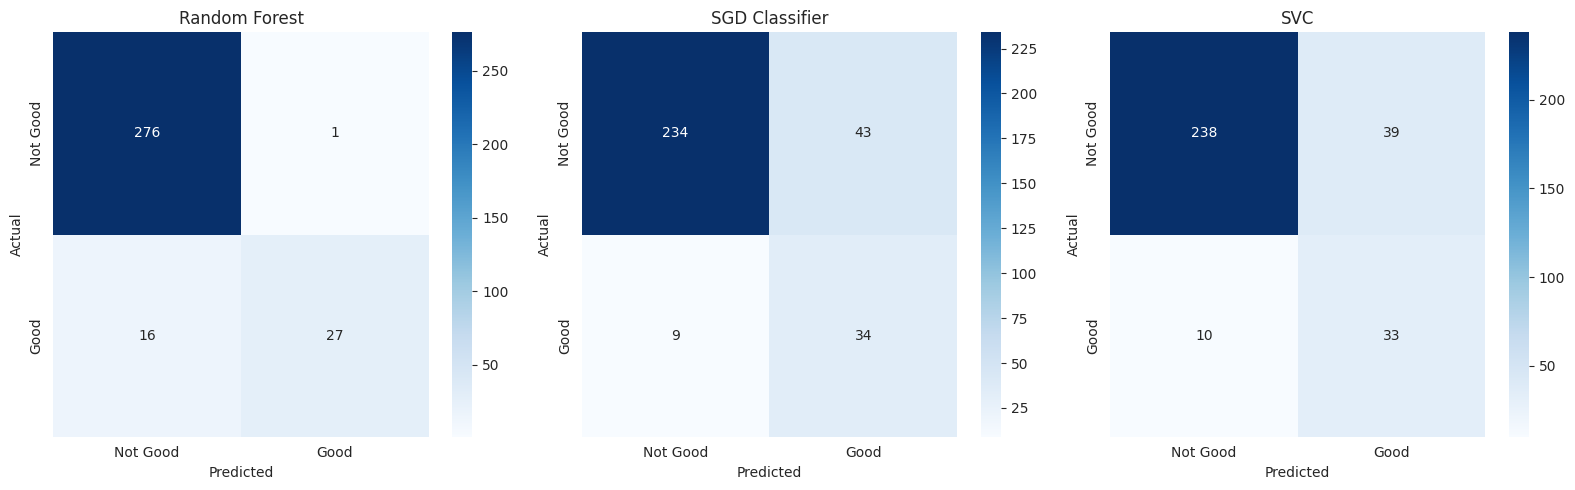

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Good', 'Good'], yticklabels=['Not Good', 'Good'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

**Observations:**
- **Random Forest** achieves the highest overall accuracy (94.7%) and, notably, very high precision on the "Good" class (0.96) — when it predicts a wine is "Good," it's right 96% of the time. However, its recall on "Good" wines is only 0.63 — it misses over a third of the actual good wines, predicting them as "Not Good" instead. Its F1 score for the minority class (0.76) is still the best of the three, because the precision gain outweighs the recall shortfall.
- **SGD Classifier** and **SVC** both trade precision for recall on the minority class: they catch more of the actual "Good" wines (recall ~0.77-0.79) but at the cost of far more false positives (precision only ~0.44-0.46) — roughly half of what they flag as "Good" isn't actually good. Their linear/RBF decision boundaries combined with `class_weight='balanced'` push them to over-predict the minority class rather than under-predict it, the opposite failure mode to Random Forest.
- Put simply: Random Forest is **cautious but accurate** when it does flag a wine as "Good," while SGD and SVC are **more willing to guess "Good"** and catch more true positives at the cost of many false alarms. Which trade-off is preferable depends on the business cost of a false positive (e.g. mislabelling a batch as premium) versus a false negative (missing a genuinely good batch) — see the conclusion below.

## 8. Feature Importance (Random Forest)

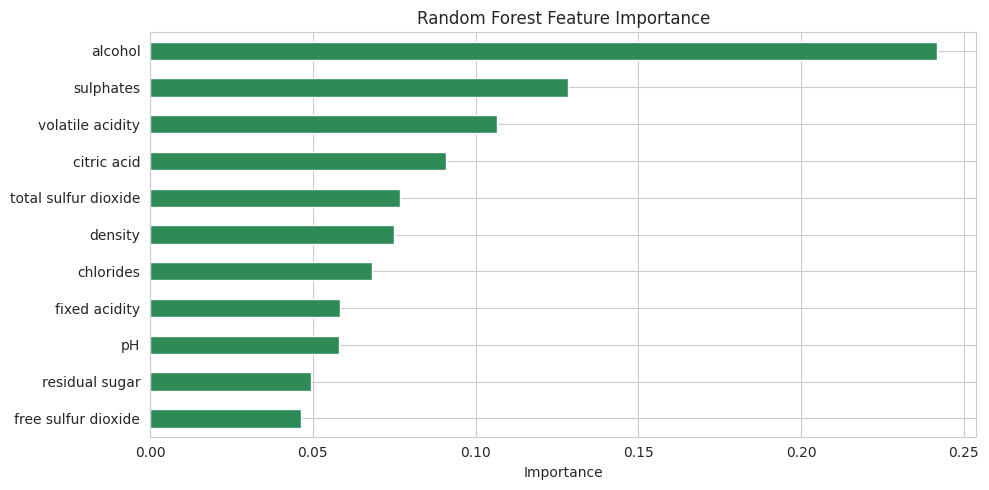

alcohol                 0.241763
sulphates               0.128350
volatile acidity        0.106453
citric acid             0.091021
total sulfur dioxide    0.076894
density                 0.075060
chlorides               0.068068
fixed acidity           0.058486
pH                      0.058008
residual sugar          0.049431
free sulfur dioxide     0.046465
dtype: float64

In [11]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots()
importances.plot(kind='barh', ax=ax, color='seagreen')
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

importances

**Observations:**
- **`alcohol`** is by far the most important feature for the Random Forest's predictions, consistent with it having the strongest raw correlation with quality in the EDA heatmap.
- **`sulphates`** and **`volatile acidity`** are the next most influential features — again aligning with the correlation analysis, which gives confidence that the model is learning genuine chemical relationships rather than noise.
- Features like `residual sugar` and `fixed acidity` contribute comparatively little to the model's decisions, suggesting they could potentially be dropped in a simplified deployment model with minimal accuracy loss (not done here, to keep the model comparison fair and consistent across all three classifiers).

## 9. Model Comparison

In [12]:
comparison = pd.DataFrame({
    name: {
        'Accuracy': res['accuracy'],
        'Precision (Good)': res['precision'],
        'Recall (Good)': res['recall'],
        'F1 Score (Good)': res['f1'],
    }
    for name, res in results.items()
}).T.round(3)

comparison

,Accuracy,Precision (Good),Recall (Good),F1 Score (Good)
Random Forest,0.947,0.964,0.628,0.761
SGD Classifier,0.838,0.442,0.791,0.567
SVC,0.847,0.458,0.767,0.574


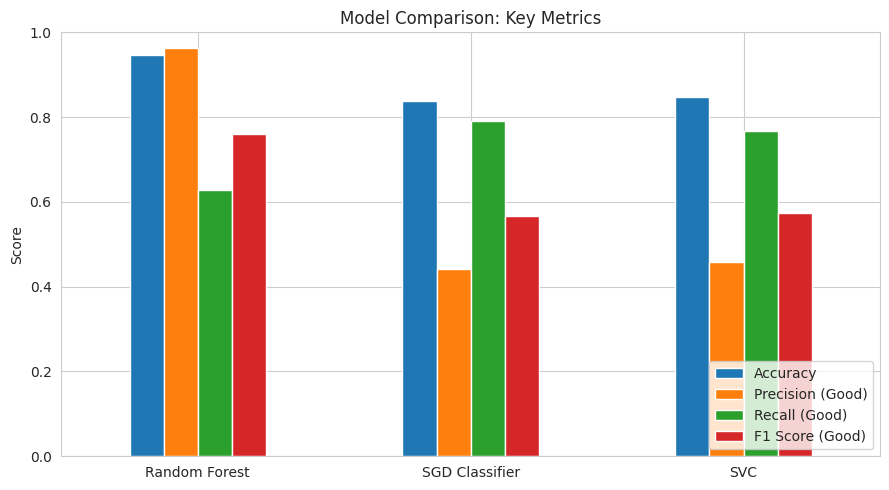

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison.plot(kind='bar', ax=ax)
ax.set_title('Model Comparison: Key Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 10. Conclusion

**Summary of findings:**
- The raw 6-class quality problem (scores 3–8) is too imbalanced to model reliably — two classes have fewer than 20 samples each. Binning into a binary **"Good" (≥7) vs. "Not Good" (≤6)** target made the problem tractable while preserving a meaningful, actionable distinction.
- `alcohol`, `volatile acidity`, and `sulphates` are the strongest predictors of wine quality, consistent across both the correlation analysis and the Random Forest's feature importances — a good sign that the model has learned real chemical signal, not noise.
- The three models show a clear trade-off on the minority "Good" class: **Random Forest is precise (96%) but conservative** (63% recall — it misses some genuinely good wines), while **SGD and SVC are more sensitive** (~77-79% recall) **but far less precise** (~44-46% — nearly half their "Good" predictions are wrong). Random Forest's F1 score (0.76) beats both alternatives (0.57 each), meaning it strikes the better overall balance despite the lower recall.

**Recommendation: deploy the Random Forest classifier.** It has the highest overall accuracy (94.7%), the best F1 score on the class that matters most, requires no feature scaling, and its feature importances make its decisions interpretable to a non-technical stakeholder (e.g. a winemaker). It's the right default choice **if the cost of a false "Good" label is high** (e.g. mislabelling a batch as premium and disappointing a customer).

**One caveat worth flagging before deployment:** if the business cost of *missing* a genuinely good wine is actually higher than the cost of a false positive (e.g. this model feeds an initial screening step, with human tasters reviewing anything flagged "Good" anyway), then **SVC's higher recall** could be preferable despite its lower precision — it would surface more of the true "Good" wines for human review, at the cost of more wasted reviews on false positives. The right choice ultimately depends on that business trade-off, not on accuracy alone.

**Suggested next step regardless of which model is chosen:** revisit the class-imbalance handling (e.g. testing SMOTE oversampling, adjusting the classification threshold instead of using the default 0.5, or gathering more "excellent"/"poor" quality samples) to see if recall on the minority class can be improved without sacrificing as much precision.